PHASE 1: HVDC FAULT DATASET DIAGNOSTIC AUDIT

1. LOADING DATA...
✓ Dataset loaded successfully
Shape: (6720, 40)

Dataset Shape: 6720 rows × 40 columns
Memory Usage: 2.05 MB

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6720 entries, 0 to 6719
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   No Fault                6720 non-null   int64  
 1   LG_R                    6720 non-null   int64  
 2   LLG_R                   6720 non-null   int64  
 3   LLL_R                   6720 non-null   int64  
 4   LL_R                    6720 non-null   int64  
 5   LG_S                    6720 non-null   int64  
 6   LLG_S                   6720 non-null   int64  
 7   LLL_S                   6720 non-null   int64  
 8   LL_S                    6720 non-null   int64  
 9   DC_L1                   6720 non-null   int64  
 10  DC_L2                   6720 non-null   int64  
 11  DC_L3     

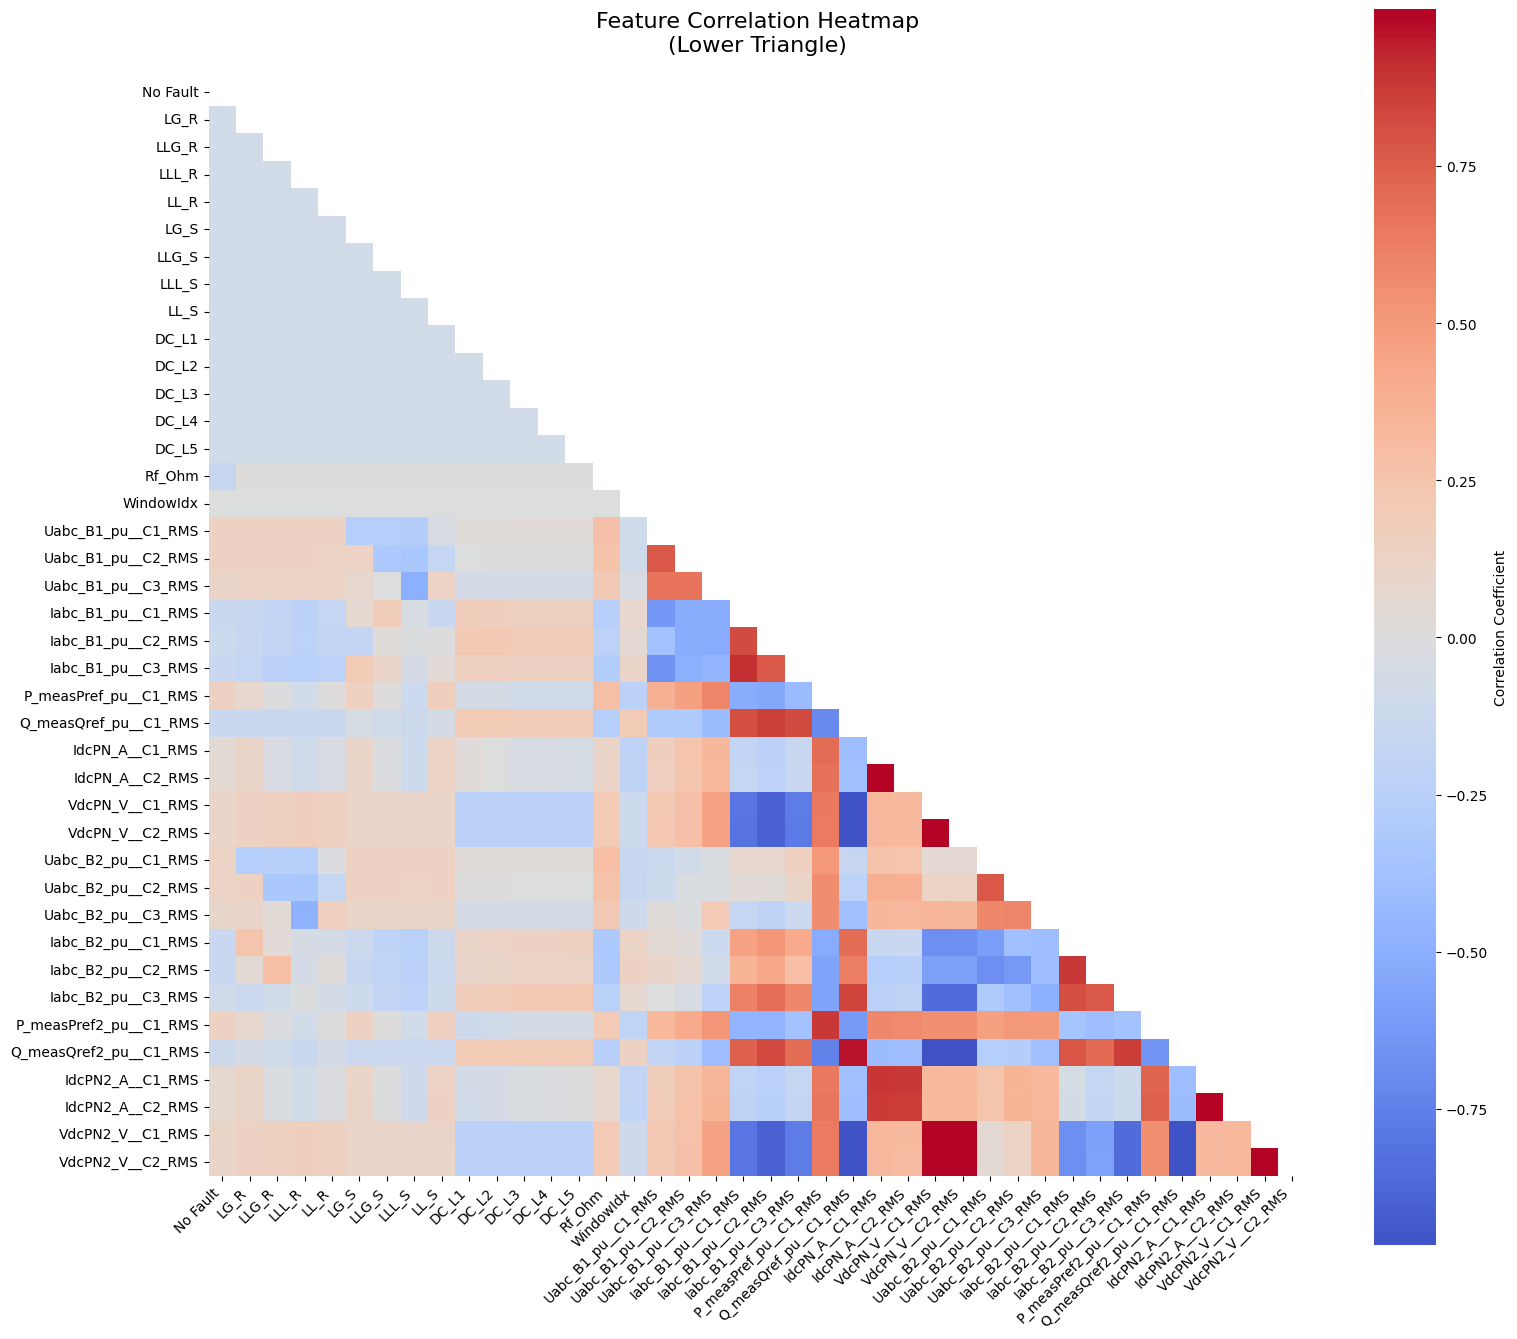


NEAR-ZERO VARIANCE ANALYSIS:
Features with variance ≤ 1e-06:
✓ No near-zero variance features found

HIGHLY CORRELATED FEATURE PAIRS:
Feature pairs with |correlation| > 0.99:
✓ No highly correlated pairs found

DIAGNOSTIC AUDIT SUMMARY:
Dataset: 6720 samples × 40 features
Missing values: 0
Duplicate rows: 96
Fault labels identified: 14
RMS features identified: 25
Near-zero variance features: 0
Highly correlated pairs: 0
Memory usage: 2.05 MB

✓ Phase 1 Diagnostic Audit Complete!
Ready for Phase 2 implementation upon your confirmation.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("="*80)
print("PHASE 1: HVDC FAULT DATASET DIAGNOSTIC AUDIT")
print("="*80)

# 1. LOAD DATA AND BASIC INFO
print("\n1. LOADING DATA...")
try:
   df = pd.read_csv('HVDC_Dataset.csv')
   print(f"✓ Dataset loaded successfully")
   print(f"Shape: {df.shape}")
except FileNotFoundError:
   print("❌ File 'HVDC_FaultDataset.csv' not found. Please upload the file to your Colab environment.")
   exit()

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*50)
print("DATASET INFO:")
print("="*50)
df.info()

# 2. DISPLAY FIRST 5 ROWS AND COLUMN NAMES
print("\n" + "="*50)
print("FIRST 5 ROWS:")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("ALL COLUMN NAMES:")
print("="*50)
print(f"Total columns: {len(df.columns)}")
for i, col in enumerate(df.columns, 1):
   print(f"{i:2d}. {col}")

# 3. MISSING VALUES AND DUPLICATES
print("\n" + "="*50)
print("DATA QUALITY ASSESSMENT:")
print("="*50)

missing_values = df.isnull().sum()
print(f"Missing values per column:")
if missing_values.sum() == 0:
   print("✓ No missing values found")
else:
   print(missing_values[missing_values > 0])

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count}")
if duplicate_count > 0:
   print(f"Percentage of duplicates: {duplicate_count/len(df)*100:.2f}%")

# 4. IDENTIFY FAULT LABELS AND FEATURE TYPES
print("\n" + "="*50)
print("FEATURE CATEGORIZATION:")
print("="*50)

# Try to identify one-hot fault labels (assuming they contain fault names or are binary)
fault_labels = []
rms_features = []
other_features = []

for col in df.columns:
   col_lower = col.lower()
   unique_vals = df[col].nunique()

   # Check if it's a one-hot encoded fault label (binary with 0,1 values)
   if set(df[col].unique()).issubset({0, 1}) and unique_vals == 2:
       fault_labels.append(col)
   elif 'rms' in col_lower:
       rms_features.append(col)
   elif 'resistance' in col_lower or 'window' in col_lower:
       other_features.append(col)
   else:
       # If not clearly categorized, check if it's likely a feature
       if unique_vals > 10:  # Continuous features typically have many unique values
           if col not in fault_labels:
               rms_features.append(col)
       else:
           other_features.append(col)

print(f"Identified fault labels ({len(fault_labels)}): {fault_labels}")
print(f"Identified RMS features ({len(rms_features)}): {rms_features[:5]}{'...' if len(rms_features) > 5 else ''}")
print(f"Other features ({len(other_features)}): {other_features}")

# 5. SUMMARY STATISTICS
print("\n" + "="*50)
print("SUMMARY STATISTICS:")
print("="*50)
print(df.describe())

# 6. FAULT LABEL DISTRIBUTION
print("\n" + "="*50)
print("FAULT LABEL DISTRIBUTION:")
print("="*50)

if fault_labels:
   fault_counts = {}
   for label in fault_labels:
       count = df[label].sum()
       fault_counts[label] = count
       print(f"{label}: {count} samples ({count/len(df)*100:.1f}%)")

   print(f"\nTotal fault samples: {sum(fault_counts.values())}")
   print(f"Expected total (if mutually exclusive): {len(df)}")

   # Check if one-hot encoding is mutually exclusive
   fault_sum_per_row = df[fault_labels].sum(axis=1)
   print(f"Samples per row - Min: {fault_sum_per_row.min()}, Max: {fault_sum_per_row.max()}")

   if fault_sum_per_row.min() == 1 and fault_sum_per_row.max() == 1:
       print("✓ One-hot encoding is mutually exclusive (exactly one fault per sample)")
   else:
       print("⚠ One-hot encoding may not be mutually exclusive")

# 7. CORRELATION HEATMAP
print("\n" + "="*50)
print("GENERATING CORRELATION HEATMAP...")
print("="*50)

# Calculate correlation matrix
corr_matrix = df.corr()

# Create figure with appropriate size
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
           mask=mask,
           annot=False,
           cmap='coolwarm',
           center=0,
           square=True,
           fmt='.2f',
           cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap\n(Lower Triangle)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. NEAR-ZERO VARIANCE FEATURES
print("\n" + "="*50)
print("NEAR-ZERO VARIANCE ANALYSIS:")
print("="*50)

variance_threshold = 1e-6
feature_variances = df.var()
low_variance_features = feature_variances[feature_variances <= variance_threshold]

print(f"Features with variance ≤ {variance_threshold}:")
if len(low_variance_features) == 0:
   print("✓ No near-zero variance features found")
else:
   for feature, variance in low_variance_features.items():
       print(f"  {feature}: {variance:.2e}")

# 9. HIGHLY CORRELATED PAIRS
print("\n" + "="*50)
print("HIGHLY CORRELATED FEATURE PAIRS:")
print("="*50)

correlation_threshold = 0.99
high_corr_pairs = []

# Get upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated pairs
for i in range(len(upper_tri.columns)):
   for j in range(i):
       corr_val = upper_tri.iloc[i, j]
       if abs(corr_val) > correlation_threshold:
           high_corr_pairs.append((upper_tri.columns[i], upper_tri.columns[j], corr_val))

print(f"Feature pairs with |correlation| > {correlation_threshold}:")
if len(high_corr_pairs) == 0:
   print("✓ No highly correlated pairs found")
else:
   for feature1, feature2, corr_val in high_corr_pairs:
       print(f"  {feature1} ↔ {feature2}: {corr_val:.4f}")

# 10. SUMMARY REPORT
print("\n" + "="*80)
print("DIAGNOSTIC AUDIT SUMMARY:")
print("="*80)
print(f"Dataset: {df.shape[0]} samples × {df.shape[1]} features")
print(f"Missing values: {missing_values.sum()}")
print(f"Duplicate rows: {duplicate_count}")
print(f"Fault labels identified: {len(fault_labels)}")
print(f"RMS features identified: {len(rms_features)}")
print(f"Near-zero variance features: {len(low_variance_features)}")
print(f"Highly correlated pairs: {len(high_corr_pairs)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✓ Phase 1 Diagnostic Audit Complete!")
print("Ready for Phase 2 implementation upon your confirmation.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566 (92.05 KB)

 Trainable params: 23,438 (91.55 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/500
11/11 - 4s - 351ms/step - categorical_accuracy: 0.1931 - loss: 2.5144 - val_categorical_accuracy: 0.3019 - val_loss: 2.4615
Epoch 2/500
11/11 - 0s - 35ms/step - categorical_accuracy: 0.3457 - loss: 2.1447 - val_categorical_accuracy: 0.3517 - val_loss: 2.2461
Epoch 3/500
11/11 - 0s - 26ms/step - categorical_accuracy: 0.3821 - loss: 1.8829 - val_categorical_accuracy: 0.3509 - val_loss: 2.0243
Epoch 4/500
11/11 - 0s - 18ms/step - categorical_accuracy: 0.4227 - loss: 1.6917 - val_categorical_accuracy: 0.4008 - val_loss: 1.8817
Epoch 5/500
11/11 - 0s - 25ms/step - categorical_accuracy: 0.4433 - loss: 1.5762 - val_categorical_accuracy: 0.4091 - val_loss: 1.7716
Epoch 6/500
11/11 - 0s - 30ms/step - categorical_accuracy: 0.4597 - loss: 1.4851 - val_categorical_accuracy: 0.4453 - val_loss: 1.6903
Epoch 7/500
11/11 - 0s - 24ms/step - categorical_accuracy: 0.4774 - loss: 1.4136 - val_categorical_accuracy: 0.4551 - val_loss: 1.6254
Epoch 8/500
11/11 - 0s - 14ms/step - categorical_accur

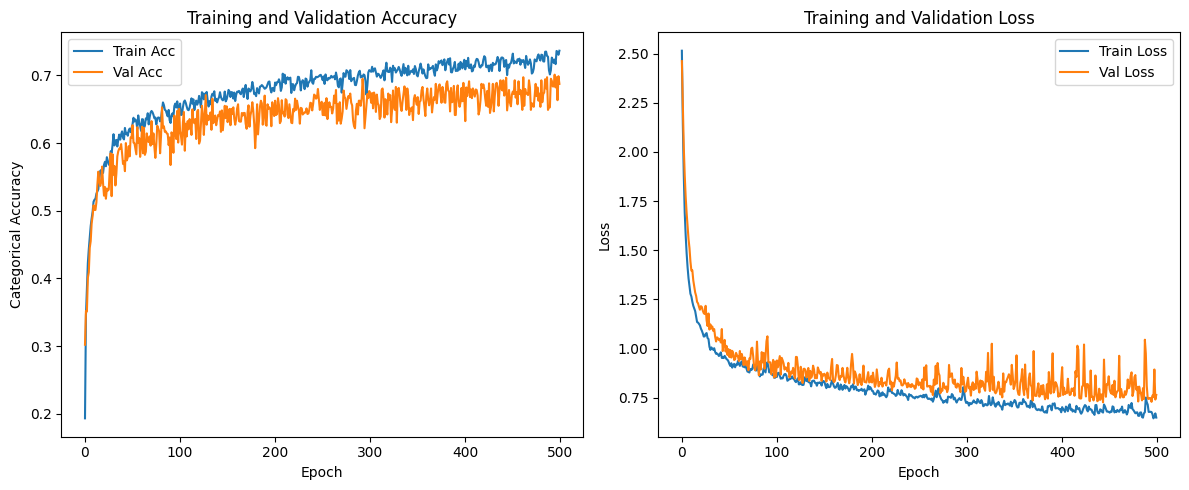

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Validation Accuracy: 68.75%


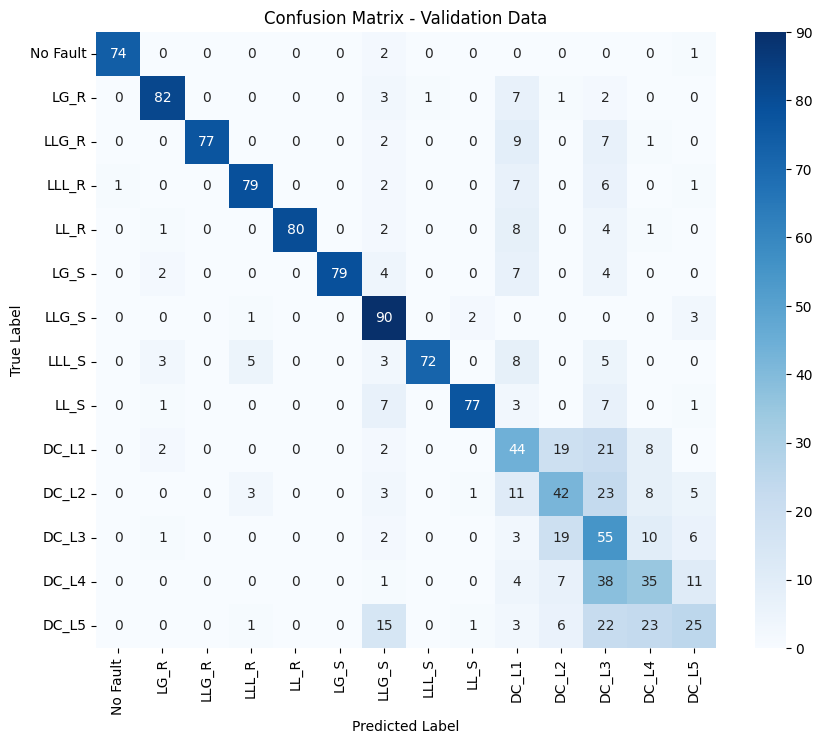

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load dataset (update path accordingly)
dataset_path = "/content/HVDC_Dataset.csv"  # <-- Change this to your actual CSV file path
df = pd.read_csv(dataset_path)

# 2. Drop duplicate rows (optional but recommended)
df = df.drop_duplicates()

# 3. Define fault label columns (targets) — your 14 one-hot columns
fault_label_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                    'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                    'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

# 4. Define feature columns as per Diagnostic Audit
# 'Rf_Ohm' + 25 RMS feature columns from your dataset
feature_cols = ['Rf_Ohm',
                'Uabc_B1_pu__C1_RMS', 'Uabc_B1_pu__C2_RMS', 'Uabc_B1_pu__C3_RMS',
                'Iabc_B1_pu__C1_RMS', 'Iabc_B1_pu__C2_RMS', 'Iabc_B1_pu__C3_RMS',
                'P_measPref_pu__C1_RMS', 'Q_measQref_pu__C1_RMS',
                'IdcPN_A__C1_RMS', 'IdcPN_A__C2_RMS',
                'VdcPN_V__C1_RMS', 'VdcPN_V__C2_RMS',
                'Uabc_B2_pu__C1_RMS', 'Uabc_B2_pu__C2_RMS', 'Uabc_B2_pu__C3_RMS',
                'Iabc_B2_pu__C1_RMS', 'Iabc_B2_pu__C2_RMS', 'Iabc_B2_pu__C3_RMS',
                'P_measPref2_pu__C1_RMS', 'Q_measQref2_pu__C1_RMS',
                'IdcPN2_A__C1_RMS', 'IdcPN2_A__C2_RMS',
                'VdcPN2_V__C1_RMS', 'VdcPN2_V__C2_RMS']

# 5. Extract features and labels
X = df[feature_cols].values
Y = df[fault_label_cols].values  # Note: already one-hot encoded

# 6. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Split into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42, stratify=Y)

# 8. Build ANN model
input_shape = X_scaled.shape[1]  # 26 features
num_classes = Y.shape[1]  # 14 fault types

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_shape,)),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),                       # Dropout layer added here
    layers.Dense(64, activation='relu'),      # New Dense layer after dropout
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['categorical_accuracy'])

model.summary()

# 9. Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=500,
    batch_size=512,
    verbose=2
)

# 10. Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.plot(history.history['categorical_accuracy'], label='Train Acc')
plt.plot(history.history['val_categorical_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Categorical Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# 11. Evaluate on validation set
y_pred_prob = model.predict(x_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

accuracy = np.mean(y_pred == y_true)
print(f'Validation Accuracy: {accuracy*100:.2f}%')

# 12. Confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
labels = fault_label_cols

plt.figure(figsize=(10,8))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Data')
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,102 (285.55 KB)

 Trainable params: 72,078 (281.55 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/500
11/11 - 5s - 461ms/step - categorical_accuracy: 0.1946 - loss: 3.1896 - val_categorical_accuracy: 0.3615 - val_loss: 2.6906
Epoch 2/500
11/11 - 0s - 29ms/step - categorical_accuracy: 0.3506 - loss: 2.4508 - val_categorical_accuracy: 0.3570 - val_loss: 2.5295
Epoch 3/500
11/11 - 0s - 24ms/step - categorical_accuracy: 0.3833 - loss: 2.2696 - val_categorical_accuracy: 0.3857 - val_loss: 2.4440
Epoch 4/500
11/11 - 0s - 28ms/step - categorical_accuracy: 0.4103 - loss: 2.1474 - val_categorical_accuracy: 0.3834 - val_loss: 2.3811
Epoch 5/500
11/11 - 0s - 26ms/step - categorical_accuracy: 0.4186 - loss: 2.0720 - val_categorical_accuracy: 0.3917 - val_loss: 2.3283
Epoch 6/500
11/11 - 0s - 25ms/step - categorical_accuracy: 0.4429 - loss: 2.0195 - val_categorical_accuracy: 0.4106 - val_loss: 2.2742
Epoch 7/500
11/11 - 0s - 26ms/step - categorical_accuracy: 0.4435 - loss: 1.9567 - val_categorical_accuracy: 0.4151 - val_loss: 2.2291
Epoch 8/500
11/11 - 0s - 23ms/step - categorical_accur

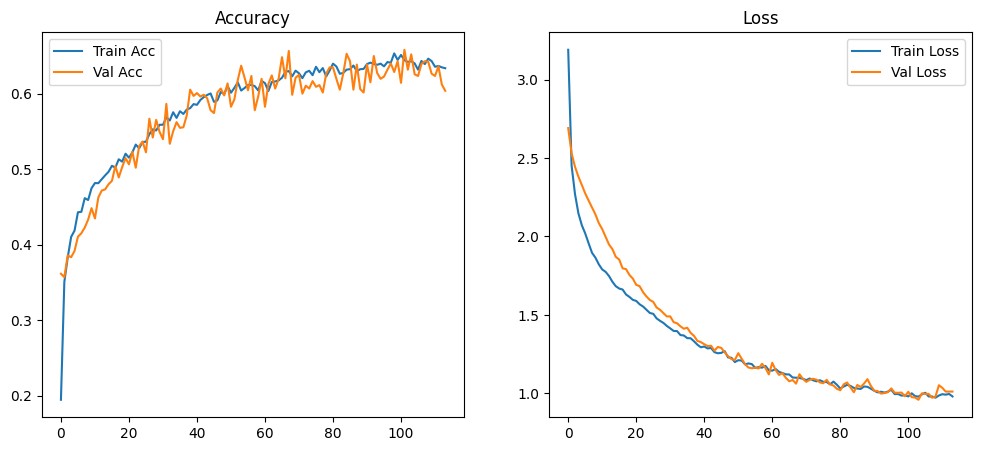

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Validation Accuracy: 65.21%


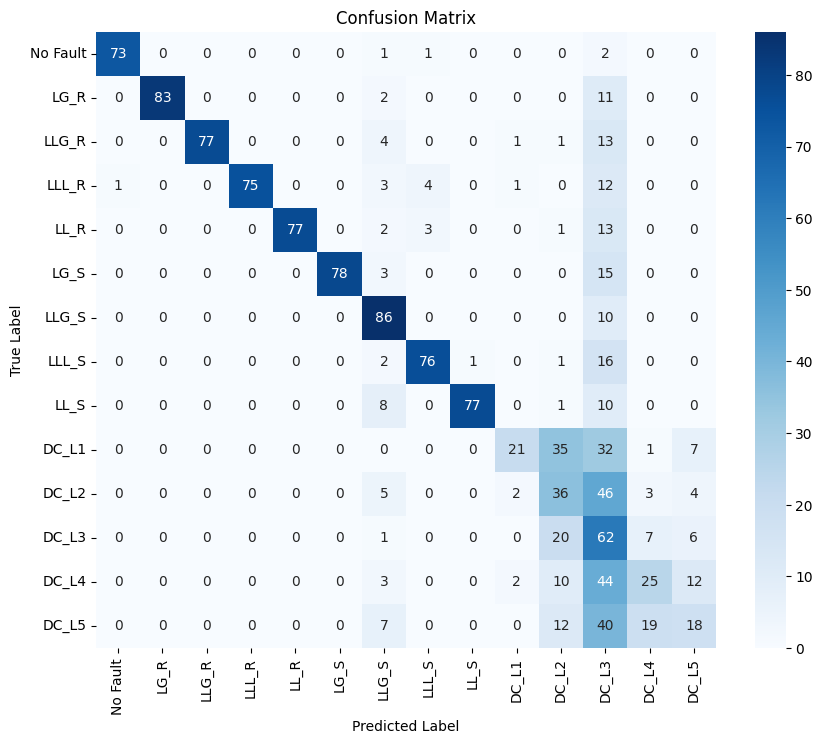

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load dataset - update path accordingly
dataset_path = "/content/HVDC_Dataset.csv"  # Replace with your dataset path
df = pd.read_csv(dataset_path)
df = df.drop_duplicates()

# Define fault label and feature columns
fault_label_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                    'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                    'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

feature_cols = ['Rf_Ohm',
                'Uabc_B1_pu__C1_RMS', 'Uabc_B1_pu__C2_RMS', 'Uabc_B1_pu__C3_RMS',
                'Iabc_B1_pu__C1_RMS', 'Iabc_B1_pu__C2_RMS', 'Iabc_B1_pu__C3_RMS',
                'P_measPref_pu__C1_RMS', 'Q_measQref_pu__C1_RMS',
                'IdcPN_A__C1_RMS', 'IdcPN_A__C2_RMS',
                'VdcPN_V__C1_RMS', 'VdcPN_V__C2_RMS',
                'Uabc_B2_pu__C1_RMS', 'Uabc_B2_pu__C2_RMS', 'Uabc_B2_pu__C3_RMS',
                'Iabc_B2_pu__C1_RMS', 'Iabc_B2_pu__C2_RMS', 'Iabc_B2_pu__C3_RMS',
                'P_measPref2_pu__C1_RMS', 'Q_measQref2_pu__C1_RMS',
                'IdcPN2_A__C1_RMS', 'IdcPN2_A__C2_RMS',
                'VdcPN2_V__C1_RMS', 'VdcPN2_V__C2_RMS']

X = df[feature_cols].values
Y = df[fault_label_cols].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data with stratification for balanced classes
x_train, x_val, y_train, y_val = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42, stratify=Y)

input_shape = X_scaled.shape[1]
num_classes = Y.shape[1]

# Build a deeper model with dropout, batch normalization, and L2 regularization
model = models.Sequential([
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(input_shape,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['categorical_accuracy'])

model.summary()

# Setup EarlyStopping callback to prevent overfitting
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model with early stopping
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=500,
    batch_size=512,
    callbacks=[early_stopping],
    verbose=2
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['categorical_accuracy'], label='Train Acc')
plt.plot(history.history['val_categorical_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Evaluate on validation set
y_pred_prob = model.predict(x_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

accuracy = np.mean(y_pred == y_true)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

# Confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=fault_label_cols, yticklabels=fault_label_cols)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


PHASE 2: HIERARCHICAL ANN CLASSIFICATION WITH SWARM-OPTIMIZED FEATURE SELECTION
Removing 96 duplicate rows...
Dataset shape after deduplication: (6624, 40)

Feature breakdown:
RMS features: 25
Other features: 1

Preparing data...
Feature matrix shape: (6624, 26)
Gate labels distribution: [ 384 3840 2400]
AC labels distribution: [480 480 480 480 480 480 480 480]
DC labels distribution: [480 480 480 480 480]

Data split:
Train: 3974 samples
Val: 1325 samples
Test: 1325 samples

TRAINING STAGE 1: GATE CLASSIFIER (Normal vs AC vs DC)
Feature space: 26 features
Training samples: 3974
Class distribution: [ 230 2304 1440]

Running GWO feature selection...
  GWO Initial best fitness: 0.9223
  GWO Iteration 0: Best fitness = 0.9262
  GWO Iteration 10: Best fitness = 0.9335
  GWO Iteration 20: Best fitness = 0.9335

Selected 14 features out of 26
Best CV fitness: 0.9335

Hyperparameter tuning...
Best hyperparameters: {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.9

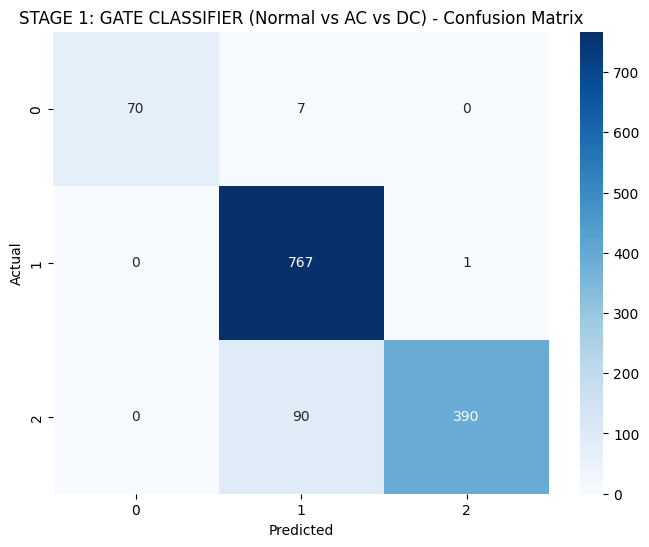


Selected features (14):
   1. Rf_Ohm
   2. Uabc_B1_pu__C1_RMS
   3. Uabc_B1_pu__C2_RMS
   4. Uabc_B1_pu__C3_RMS
   5. Q_measQref_pu__C1_RMS
   6. IdcPN_A__C1_RMS
   7. IdcPN_A__C2_RMS
   8. Uabc_B2_pu__C2_RMS
   9. Uabc_B2_pu__C3_RMS
  10. Iabc_B2_pu__C2_RMS
  11. Iabc_B2_pu__C3_RMS
  12. Q_measQref2_pu__C1_RMS
  13. IdcPN2_A__C1_RMS
  14. VdcPN2_V__C1_RMS

TRAINING STAGE 2A: AC FAULT CLASSIFIER
Feature space: 26 features
Training samples: 2304
Class distribution: [289 286 290 285 308 288 281 277]

Running PSO feature selection...
  PSO Initial best fitness: 0.7277
  PSO Iteration 0: Best fitness = 0.7277
  PSO Iteration 10: Best fitness = 0.7277
  PSO Iteration 20: Best fitness = 0.7277

Selected 14 features out of 26
Best CV fitness: 0.7277

Hyperparameter tuning...
Best hyperparameters: {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.8116

Final Results:
Train Accuracy: 0.8069
Validation Accuracy: 0.7591
Test Accuracy: 0.7513

Classification Report (Te

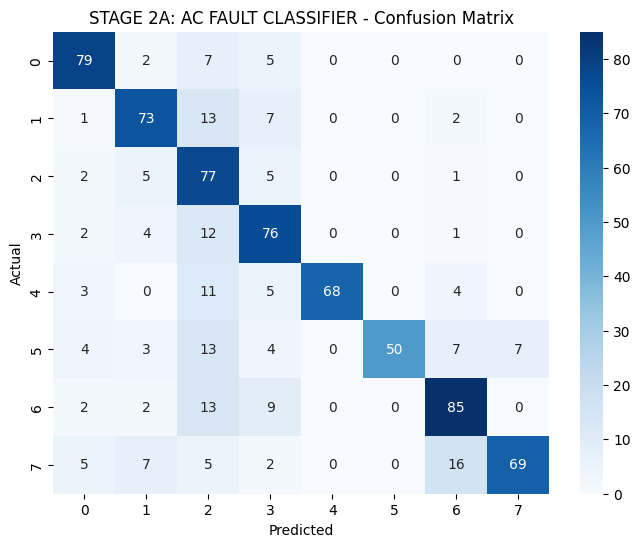


Selected features (14):
   1. Uabc_B1_pu__C2_RMS
   2. Iabc_B1_pu__C1_RMS
   3. Iabc_B1_pu__C2_RMS
   4. Iabc_B1_pu__C3_RMS
   5. Uabc_B2_pu__C1_RMS
   6. Uabc_B2_pu__C2_RMS
   7. Uabc_B2_pu__C3_RMS
   8. Iabc_B2_pu__C1_RMS
   9. Iabc_B2_pu__C2_RMS
  10. Iabc_B2_pu__C3_RMS
  11. P_measPref2_pu__C1_RMS
  12. IdcPN2_A__C1_RMS
  13. VdcPN2_V__C2_RMS
  14. WindowIdx

TRAINING STAGE 2B: DC FAULT CLASSIFIER
  Engineered 14 additional DC features
  Engineered 14 additional DC features
  Engineered 14 additional DC features
Feature space: 40 features
Training samples: 1440
Class distribution: [286 279 297 300 278]

Running CSO feature selection...
  CSO Initial best fitness: 0.2649
  CSO Iteration 0: Best fitness = 0.2675
  CSO Iteration 10: Best fitness = 0.2908
  CSO Iteration 20: Best fitness = 0.2908

Selected 17 features out of 40
Best CV fitness: 0.2951

Hyperparameter tuning...
Best hyperparameters: {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.4806

Fin

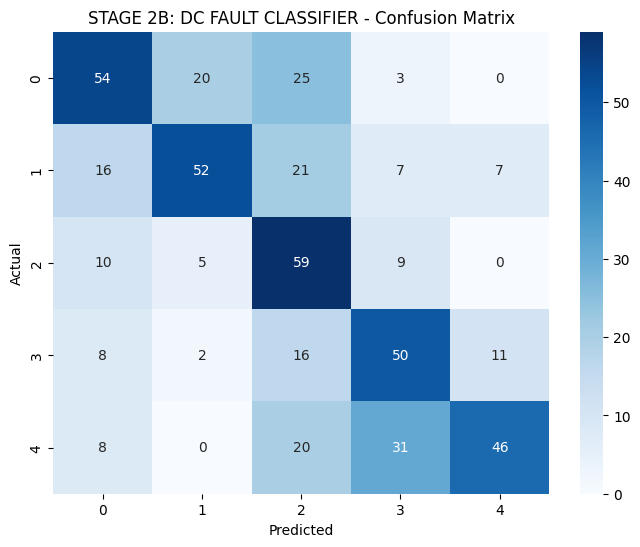


Selected features (17):
   1. Rf_Ohm
   2. Uabc_B1_pu__C3_RMS
   3. Iabc_B1_pu__C1_RMS
   4. Q_measQref_pu__C1_RMS
   5. IdcPN_A__C1_RMS
   6. IdcPN_A__C2_RMS
   7. Iabc_B2_pu__C3_RMS
   8. P_measPref2_pu__C1_RMS
   9. VdcPN2_V__C2_RMS
  10. Delta_IdcPN_A__C1_RMS_IdcPN_A__C2_RMS
  11. Delta_IdcPN_A__C1_RMS_IdcPN2_A__C2_RMS
  12. Delta_VdcPN_V__C1_RMS_VdcPN_V__C2_RMS
  13. Delta_VdcPN_V__C1_RMS_VdcPN2_V__C1_RMS
  14. Delta_VdcPN_V__C1_RMS_VdcPN2_V__C2_RMS
  15. Delta_VdcPN_V__C2_RMS_VdcPN2_V__C1_RMS
  16. Delta_VdcPN_V__C2_RMS_VdcPN2_V__C2_RMS
  17. Ratio_VdcPN_V__C1_RMS_VdcPN_V__C2_RMS

HIERARCHICAL CLASSIFICATION RESULTS SUMMARY
Stage 1 (Gate) - Test Accuracy: 0.9260
  Selected features: 14
  Algorithm: GWO

Stage 2A (AC) - Test Accuracy: 0.7513
  Selected features: 14
  Algorithm: PSO

Stage 2B (DC) - Test Accuracy: 0.5437
  Selected features: 17
  Algorithm: CSO

Overall pipeline performance:
  Average accuracy: 0.7404
  Total selected features: 30

✓ Phase 2 Hierarchical Classific

In [ ]:
# PHASE 2: HIERARCHICAL ANN CLASSIFICATION WITH SWARM-OPTIMIZED FEATURE SELECTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Swarm optimization algorithms
import random
from typing import List, Tuple, Callable
import time

print("="*80)
print("PHASE 2: HIERARCHICAL ANN CLASSIFICATION WITH SWARM-OPTIMIZED FEATURE SELECTION")
print("="*80)

# Load data
df = pd.read_csv('HVDC_Dataset.csv')

# Remove duplicates
print(f"Removing {df.duplicated().sum()} duplicate rows...")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after deduplication: {df.shape}")

# Define feature categories
fault_labels = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
               'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
rms_features = [col for col in df.columns if 'RMS' in col or col == 'Rf_Ohm']
other_features = ['WindowIdx']

print(f"\nFeature breakdown:")
print(f"RMS features: {len(rms_features)}")
print(f"Other features: {len(other_features)}")

# =============================================================================
# SWARM OPTIMIZATION ALGORITHMS
# =============================================================================

class SwarmOptimizer:
   def __init__(self, n_features: int, n_particles: int = 20, max_iter: int = 30):
       self.n_features = n_features
       self.n_particles = n_particles
       self.max_iter = max_iter
       self.best_global_position = None
       self.best_global_fitness = -np.inf

   def evaluate_fitness(self, position: np.ndarray, X_train: np.ndarray, y_train: np.ndarray) -> float:
       """Evaluate fitness using cross-validation accuracy"""
       # Convert position to binary feature mask
       feature_mask = position > 0.5

       # Must select at least 2 features
       if np.sum(feature_mask) < 2:
           return -1.0

       # Select features
       X_selected = X_train[:, feature_mask]

       # Use MLPClassifier with cross-validation
       mlp = MLPClassifier(
           hidden_layer_sizes=(50, 25),
           max_iter=200,
           random_state=42,
           early_stopping=True,
           validation_fraction=0.2
       )

       # 3-fold CV for speed
       cv_scores = cross_val_score(mlp, X_selected, y_train, cv=3, scoring='accuracy')

       # Fitness = accuracy - penalty for too many features
       n_selected = np.sum(feature_mask)
       penalty = 0.01 * (n_selected / self.n_features)  # Small penalty for complexity

       return cv_scores.mean() - penalty

class GWO(SwarmOptimizer):
   """Grey Wolf Optimizer"""

   def optimize(self, X_train: np.ndarray, y_train: np.ndarray) -> Tuple[np.ndarray, float]:
       # Initialize wolves
       wolves = np.random.rand(self.n_particles, self.n_features)
       fitness = np.array([self.evaluate_fitness(wolf, X_train, y_train) for wolf in wolves])

       # Sort wolves
       sorted_indices = np.argsort(fitness)[::-1]
       alpha = wolves[sorted_indices[0]]
       beta = wolves[sorted_indices[1]]
       delta = wolves[sorted_indices[2]]

       best_fitness = fitness[sorted_indices[0]]
       print(f"  GWO Initial best fitness: {best_fitness:.4f}")

       for iteration in range(self.max_iter):
           a = 2 - iteration * (2 / self.max_iter)  # Decreasing from 2 to 0

           for i in range(self.n_particles):
               # Update position based on alpha, beta, delta
               for j in range(self.n_features):
                   r1, r2 = np.random.rand(2)
                   A1 = 2 * a * r1 - a
                   C1 = 2 * r2
                   D_alpha = abs(C1 * alpha[j] - wolves[i][j])
                   X1 = alpha[j] - A1 * D_alpha

                   r1, r2 = np.random.rand(2)
                   A2 = 2 * a * r1 - a
                   C2 = 2 * r2
                   D_beta = abs(C2 * beta[j] - wolves[i][j])
                   X2 = beta[j] - A2 * D_beta

                   r1, r2 = np.random.rand(2)
                   A3 = 2 * a * r1 - a
                   C3 = 2 * r2
                   D_delta = abs(C3 * delta[j] - wolves[i][j])
                   X3 = delta[j] - A3 * D_delta

                   wolves[i][j] = (X1 + X2 + X3) / 3

               # Clip to [0, 1]
               wolves[i] = np.clip(wolves[i], 0, 1)

           # Update fitness
           fitness = np.array([self.evaluate_fitness(wolf, X_train, y_train) for wolf in wolves])

           # Update alpha, beta, delta
           sorted_indices = np.argsort(fitness)[::-1]
           if fitness[sorted_indices[0]] > best_fitness:
               alpha = wolves[sorted_indices[0]].copy()
               beta = wolves[sorted_indices[1]].copy()
               delta = wolves[sorted_indices[2]].copy()
               best_fitness = fitness[sorted_indices[0]]

           if iteration % 10 == 0:
               print(f"  GWO Iteration {iteration}: Best fitness = {best_fitness:.4f}")

       return alpha, best_fitness

class PSO(SwarmOptimizer):
   """Particle Swarm Optimization"""

   def optimize(self, X_train: np.ndarray, y_train: np.ndarray) -> Tuple[np.ndarray, float]:
       # Initialize particles
       particles = np.random.rand(self.n_particles, self.n_features)
       velocities = np.random.rand(self.n_particles, self.n_features) * 0.1

       # Personal best
       personal_best = particles.copy()
       personal_best_fitness = np.array([self.evaluate_fitness(p, X_train, y_train) for p in particles])

       # Global best
       global_best_idx = np.argmax(personal_best_fitness)
       global_best = personal_best[global_best_idx].copy()
       global_best_fitness = personal_best_fitness[global_best_idx]

       print(f"  PSO Initial best fitness: {global_best_fitness:.4f}")

       w = 0.9  # Inertia weight
       c1 = 2.0  # Personal acceleration
       c2 = 2.0  # Global acceleration

       for iteration in range(self.max_iter):
           # Decrease inertia weight
           w = 0.9 - 0.5 * iteration / self.max_iter

           for i in range(self.n_particles):
               # Update velocity
               r1, r2 = np.random.rand(2)
               velocities[i] = (w * velocities[i] +
                              c1 * r1 * (personal_best[i] - particles[i]) +
                              c2 * r2 * (global_best - particles[i]))

               # Update position
               particles[i] += velocities[i]
               particles[i] = np.clip(particles[i], 0, 1)

               # Update personal best
               fitness = self.evaluate_fitness(particles[i], X_train, y_train)
               if fitness > personal_best_fitness[i]:
                   personal_best[i] = particles[i].copy()
                   personal_best_fitness[i] = fitness

                   # Update global best
                   if fitness > global_best_fitness:
                       global_best = particles[i].copy()
                       global_best_fitness = fitness

           if iteration % 10 == 0:
               print(f"  PSO Iteration {iteration}: Best fitness = {global_best_fitness:.4f}")

       return global_best, global_best_fitness

class CSO(SwarmOptimizer):
   """Cuckoo Search Optimization"""

   def optimize(self, X_train: np.ndarray, y_train: np.ndarray) -> Tuple[np.ndarray, float]:
       # Initialize nests
       nests = np.random.rand(self.n_particles, self.n_features)
       fitness = np.array([self.evaluate_fitness(nest, X_train, y_train) for nest in nests])

       best_idx = np.argmax(fitness)
       best_nest = nests[best_idx].copy()
       best_fitness = fitness[best_idx]

       print(f"  CSO Initial best fitness: {best_fitness:.4f}")

       pa = 0.25  # Discovery rate

       for iteration in range(self.max_iter):
           # Levy flights
           for i in range(self.n_particles):
               # Generate new solution via Levy flight
               levy = np.random.normal(0, 1, self.n_features)
               step_size = 0.01
               new_nest = nests[i] + step_size * levy
               new_nest = np.clip(new_nest, 0, 1)

               # Evaluate fitness
               new_fitness = self.evaluate_fitness(new_nest, X_train, y_train)

               # Replace if better
               if new_fitness > fitness[i]:
                   nests[i] = new_nest
                   fitness[i] = new_fitness

                   if new_fitness > best_fitness:
                       best_nest = new_nest.copy()
                       best_fitness = new_fitness

           # Abandon worst nests
           n_abandon = int(pa * self.n_particles)
           worst_indices = np.argsort(fitness)[:n_abandon]

           for idx in worst_indices:
               nests[idx] = np.random.rand(self.n_features)
               fitness[idx] = self.evaluate_fitness(nests[idx], X_train, y_train)

           if iteration % 10 == 0:
               print(f"  CSO Iteration {iteration}: Best fitness = {best_fitness:.4f}")

       return best_nest, best_fitness

# =============================================================================
# CLASSIFICATION PIPELINE
# =============================================================================

def create_hierarchical_labels(df):
   """Create hierarchical labels for three stages"""
   fault_labels = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                   'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

   # Find which fault is active for each sample
   y_detailed = []
   for idx, row in df.iterrows():
       for fault in fault_labels:
           if row[fault] == 1:
               y_detailed.append(fault)
               break

   # Stage 1: Gate classifier (Normal vs AC vs DC)
   y_gate = []
   for fault in y_detailed:
       if fault == 'No Fault':
           y_gate.append(0)  # Normal
       elif fault.startswith('DC_'):
           y_gate.append(2)  # DC fault
       else:
           y_gate.append(1)  # AC fault

   # Stage 2a: AC fault classification
   ac_faults = ['LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S']
   y_ac = []
   for fault in y_detailed:
       if fault in ac_faults:
           y_ac.append(ac_faults.index(fault))
       else:
           y_ac.append(-1)  # Not AC fault

   # Stage 2b: DC fault classification
   dc_faults = ['DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
   y_dc = []
   for fault in y_detailed:
       if fault in dc_faults:
           y_dc.append(dc_faults.index(fault))
       else:
           y_dc.append(-1)  # Not DC fault

   return np.array(y_gate), np.array(y_ac), np.array(y_dc), y_detailed

def engineer_dc_features(X, feature_names):
   """Engineer additional features for DC fault classification"""
   X_engineered = X.copy()
   feature_names_new = feature_names.copy()

   # Find DC-related features
   dc_current_cols = [i for i, name in enumerate(feature_names) if 'IdcPN' in name]
   dc_voltage_cols = [i for i, name in enumerate(feature_names) if 'VdcPN' in name]

   # Add delta features (differences between poles/terminals)
   if len(dc_current_cols) >= 2:
       for i in range(len(dc_current_cols)):
           for j in range(i+1, len(dc_current_cols)):
               delta_feature = X[:, dc_current_cols[i]] - X[:, dc_current_cols[j]]
               X_engineered = np.column_stack([X_engineered, delta_feature])
               feature_names_new.append(f"Delta_{feature_names[dc_current_cols[i]]}_{feature_names[dc_current_cols[j]]}")

   if len(dc_voltage_cols) >= 2:
       for i in range(len(dc_voltage_cols)):
           for j in range(i+1, len(dc_voltage_cols)):
               delta_feature = X[:, dc_voltage_cols[i]] - X[:, dc_voltage_cols[j]]
               X_engineered = np.column_stack([X_engineered, delta_feature])
               feature_names_new.append(f"Delta_{feature_names[dc_voltage_cols[i]]}_{feature_names[dc_voltage_cols[j]]}")

   # Add ratio features
   if len(dc_current_cols) >= 2:
       ratio_feature = X[:, dc_current_cols[0]] / (X[:, dc_current_cols[1]] + 1e-6)
       X_engineered = np.column_stack([X_engineered, ratio_feature])
       feature_names_new.append(f"Ratio_{feature_names[dc_current_cols[0]]}_{feature_names[dc_current_cols[1]]}")

   if len(dc_voltage_cols) >= 2:
       ratio_feature = X[:, dc_voltage_cols[0]] / (X[:, dc_voltage_cols[1]] + 1e-6)
       X_engineered = np.column_stack([X_engineered, ratio_feature])
       feature_names_new.append(f"Ratio_{feature_names[dc_voltage_cols[0]]}_{feature_names[dc_voltage_cols[1]]}")

   print(f"  Engineered {X_engineered.shape[1] - X.shape[1]} additional DC features")
   return X_engineered, feature_names_new

def train_stage_classifier(X_train, y_train, X_val, y_val, X_test, y_test,
                        feature_names, stage_name, swarm_algorithm='GWO',
                        engineer_features=False):
   """Train classifier for one stage with swarm optimization"""
   print(f"\n{'='*60}")
   print(f"TRAINING {stage_name}")
   print(f"{'='*60}")

   # Engineer features if needed (for DC stage)
   if engineer_features:
       X_train_eng, feature_names_eng = engineer_dc_features(X_train, feature_names)
       X_val_eng, _ = engineer_dc_features(X_val, feature_names)
       X_test_eng, _ = engineer_dc_features(X_test, feature_names)
   else:
       X_train_eng, X_val_eng, X_test_eng = X_train, X_val, X_test
       feature_names_eng = feature_names

   print(f"Feature space: {X_train_eng.shape[1]} features")
   print(f"Training samples: {len(X_train_eng)}")
   print(f"Class distribution: {np.bincount(y_train)}")

   # Initialize swarm optimizer
   if swarm_algorithm == 'GWO':
       optimizer = GWO(n_features=X_train_eng.shape[1])
   elif swarm_algorithm == 'PSO':
       optimizer = PSO(n_features=X_train_eng.shape[1])
   else:  # CSO
       optimizer = CSO(n_features=X_train_eng.shape[1])

   # Run optimization
   print(f"\nRunning {swarm_algorithm} feature selection...")
   best_position, best_fitness = optimizer.optimize(X_train_eng, y_train)

   # Extract selected features
   feature_mask = best_position > 0.5
   selected_features = np.where(feature_mask)[0]

   print(f"\nSelected {len(selected_features)} features out of {len(feature_mask)}")
   print(f"Best CV fitness: {best_fitness:.4f}")

   # Train final model with selected features
   X_train_selected = X_train_eng[:, feature_mask]
   X_val_selected = X_val_eng[:, feature_mask]
   X_test_selected = X_test_eng[:, feature_mask]

   # Hyperparameter tuning
   print("\nHyperparameter tuning...")
   best_score = 0
   best_params = None

   param_grid = [
       {'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01},
       {'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001},
       {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01},
       {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001},
       {'hidden_layer_sizes': (100, 50, 25), 'learning_rate_init': 0.001},
   ]

   for params in param_grid:
       mlp = MLPClassifier(
           hidden_layer_sizes=params['hidden_layer_sizes'],
           learning_rate_init=params['learning_rate_init'],
           max_iter=500,
           random_state=42,
           early_stopping=True,
           validation_fraction=0.2
       )

       # Cross-validation
       cv_scores = cross_val_score(mlp, X_train_selected, y_train, cv=5, scoring='accuracy')
       mean_score = cv_scores.mean()

       if mean_score > best_score:
           best_score = mean_score
           best_params = params

   print(f"Best hyperparameters: {best_params}")
   print(f"Best CV score: {best_score:.4f}")

   # Train final model
   final_model = MLPClassifier(
       hidden_layer_sizes=best_params['hidden_layer_sizes'],
       learning_rate_init=best_params['learning_rate_init'],
       max_iter=500,
       random_state=42,
       early_stopping=True,
       validation_fraction=0.2
   )

   final_model.fit(X_train_selected, y_train)

   # Evaluate
   train_pred = final_model.predict(X_train_selected)
   val_pred = final_model.predict(X_val_selected)
   test_pred = final_model.predict(X_test_selected)

   train_acc = accuracy_score(y_train, train_pred)
   val_acc = accuracy_score(y_val, val_pred)
   test_acc = accuracy_score(y_test, test_pred)

   print(f"\nFinal Results:")
   print(f"Train Accuracy: {train_acc:.4f}")
   print(f"Validation Accuracy: {val_acc:.4f}")
   print(f"Test Accuracy: {test_acc:.4f}")

   # Classification report
   print(f"\nClassification Report (Test Set):")
   print(classification_report(y_test, test_pred))

   # Confusion matrix
   cm = confusion_matrix(y_test, test_pred)
   plt.figure(figsize=(8, 6))
   sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
   plt.title(f'{stage_name} - Confusion Matrix')
   plt.xlabel('Predicted')
   plt.ylabel('Actual')
   plt.show()

   # Feature importance (selected features)
   selected_feature_names = [feature_names_eng[i] for i in selected_features]
   print(f"\nSelected features ({len(selected_feature_names)}):")
   for i, name in enumerate(selected_feature_names):
       print(f"  {i+1:2d}. {name}")

   return final_model, feature_mask, test_acc, selected_feature_names

# =============================================================================
# MAIN EXECUTION
# =============================================================================

# Prepare data
print("\nPreparing data...")
X = df[rms_features + other_features].values
feature_names = rms_features + other_features

# Create hierarchical labels
y_gate, y_ac, y_dc, y_detailed = create_hierarchical_labels(df)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Gate labels distribution: {np.bincount(y_gate)}")
print(f"AC labels distribution: {np.bincount(y_ac[y_ac >= 0])}")
print(f"DC labels distribution: {np.bincount(y_dc[y_dc >= 0])}")

# Split data stratified by gate labels
X_temp, X_test, y_gate_temp, y_gate_test = train_test_split(
   X_scaled, y_gate, test_size=0.2, stratify=y_gate, random_state=42
)
X_train, X_val, y_gate_train, y_gate_val = train_test_split(
   X_temp, y_gate_temp, test_size=0.25, stratify=y_gate_temp, random_state=42
)

# Store corresponding AC and DC labels
y_ac_train = y_ac[X_train.index] if hasattr(X_train, 'index') else y_ac[:len(X_train)]
y_ac_val = y_ac[X_val.index] if hasattr(X_val, 'index') else y_ac[len(X_train):len(X_train)+len(X_val)]
y_ac_test = y_ac[X_test.index] if hasattr(X_test, 'index') else y_ac[len(X_train)+len(X_val):]

y_dc_train = y_dc[X_train.index] if hasattr(X_train, 'index') else y_dc[:len(X_train)]
y_dc_val = y_dc[X_val.index] if hasattr(X_val, 'index') else y_dc[len(X_train):len(X_train)+len(X_val)]
y_dc_test = y_dc[X_test.index] if hasattr(X_test, 'index') else y_dc[len(X_train)+len(X_val):]

# Fix index issues
temp_indices = np.arange(len(X_scaled))
train_indices, test_indices = train_test_split(temp_indices, test_size=0.2, stratify=y_gate, random_state=42)
train_indices, val_indices = train_test_split(train_indices, test_size=0.25, stratify=y_gate[train_indices], random_state=42)

X_train, X_val, X_test = X_scaled[train_indices], X_scaled[val_indices], X_scaled[test_indices]
y_gate_train, y_gate_val, y_gate_test = y_gate[train_indices], y_gate[val_indices], y_gate[test_indices]
y_ac_train, y_ac_val, y_ac_test = y_ac[train_indices], y_ac[val_indices], y_ac[test_indices]
y_dc_train, y_dc_val, y_dc_test = y_dc[train_indices], y_dc[val_indices], y_dc[test_indices]

print(f"\nData split:")
print(f"Train: {len(X_train)} samples")
print(f"Val: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

# =============================================================================
# STAGE 1: GATE CLASSIFIER (Normal vs AC vs DC)
# =============================================================================

gate_model, gate_mask, gate_acc, gate_features = train_stage_classifier(
   X_train, y_gate_train, X_val, y_gate_val, X_test, y_gate_test,
   feature_names, "STAGE 1: GATE CLASSIFIER (Normal vs AC vs DC)",
   swarm_algorithm='GWO'
)

# =============================================================================
# STAGE 2A: AC FAULT CLASSIFIER
# =============================================================================

# Filter for AC fault samples only
ac_mask_train = y_ac_train >= 0
ac_mask_val = y_ac_val >= 0
ac_mask_test = y_ac_test >= 0

X_train_ac = X_train[ac_mask_train]
X_val_ac = X_val[ac_mask_val]
X_test_ac = X_test[ac_mask_test]

y_train_ac = y_ac_train[ac_mask_train]
y_val_ac = y_ac_val[ac_mask_val]
y_test_ac = y_ac_test[ac_mask_test]

ac_model, ac_mask, ac_acc, ac_features = train_stage_classifier(
   X_train_ac, y_train_ac, X_val_ac, y_val_ac, X_test_ac, y_test_ac,
   feature_names, "STAGE 2A: AC FAULT CLASSIFIER",
   swarm_algorithm='PSO'
)

# =============================================================================
# STAGE 2B: DC FAULT CLASSIFIER
# =============================================================================

# Filter for DC fault samples only
dc_mask_train = y_dc_train >= 0
dc_mask_val = y_dc_val >= 0
dc_mask_test = y_dc_test >= 0

X_train_dc = X_train[dc_mask_train]
X_val_dc = X_val[dc_mask_val]
X_test_dc = X_test[dc_mask_test]

y_train_dc = y_dc_train[dc_mask_train]
y_val_dc = y_dc_val[dc_mask_val]
y_test_dc = y_dc_test[dc_mask_test]

dc_model, dc_mask, dc_acc, dc_features = train_stage_classifier(
   X_train_dc, y_train_dc, X_val_dc, y_val_dc, X_test_dc, y_test_dc,
   feature_names, "STAGE 2B: DC FAULT CLASSIFIER",
   swarm_algorithm='CSO', engineer_features=True
)

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("HIERARCHICAL CLASSIFICATION RESULTS SUMMARY")
print("="*80)
print(f"Stage 1 (Gate) - Test Accuracy: {gate_acc:.4f}")
print(f"  Selected features: {len(gate_features)}")
print(f"  Algorithm: GWO")

print(f"\nStage 2A (AC) - Test Accuracy: {ac_acc:.4f}")
print(f"  Selected features: {len(ac_features)}")
print(f"  Algorithm: PSO")

print(f"\nStage 2B (DC) - Test Accuracy: {dc_acc:.4f}")
print(f"  Selected features: {len(dc_features)}")
print(f"  Algorithm: CSO")

print(f"\nOverall pipeline performance:")
print(f"  Average accuracy: {(gate_acc + ac_acc + dc_acc) / 3:.4f}")
print(f"  Total selected features: {len(set(gate_features + ac_features + dc_features))}")

print("\n✓ Phase 2 Hierarchical Classification Complete!")

Removing 96 duplicate rows...
Dataset shape after deduplication: (6624, 40)
RMS features: 25, Other features: 1

Data split sizes: Train=3974, Val=1325, Test=1325

Run 1 / 5 - Stage 1 (Gate)

TRAINING Stage 1 (Gate)
Feature space: 26 features
Training samples: 3974
Class distribution: [ 230 2304 1440]

Running GWO feature selection...
GWO Iter 0 - Best fitness: 0.9258
GWO Iter 10 - Best fitness: 0.9317
GWO Iter 20 - Best fitness: 0.9325

Selected 8 features out of 26
Best CV fitness: 0.9325
Best hyperparameters: {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best CV score: 0.9399

Final Results:
Train Accuracy: 0.9441
Validation Accuracy: 0.9374
Test Accuracy: 0.9291

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.90      0.94        77
           1       0.89      1.00      0.94       768
           2       0.99      0.82      0.90       480

    accuracy                           0.93      1325
   

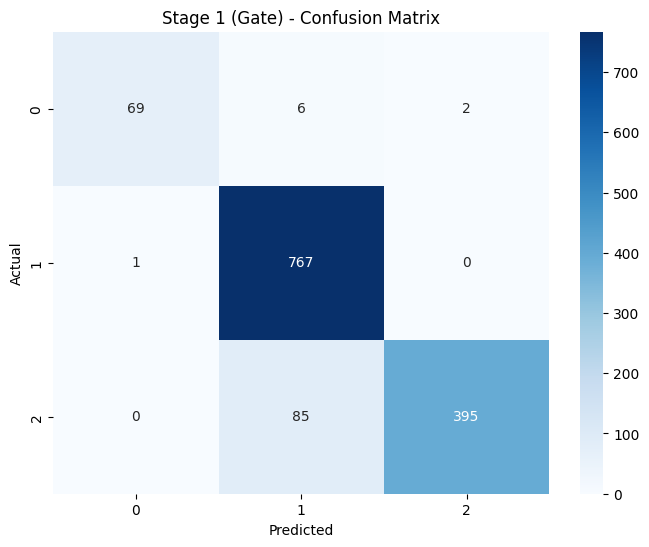


Selected features (8):
   1. Rf_Ohm
   2. Uabc_B1_pu__C1_RMS
   3. Iabc_B1_pu__C3_RMS
   4. IdcPN_A__C1_RMS
   5. VdcPN_V__C1_RMS
   6. Iabc_B2_pu__C1_RMS
   7. Iabc_B2_pu__C2_RMS
   8. Q_measQref2_pu__C1_RMS

Run 2 / 5 - Stage 1 (Gate)

TRAINING Stage 1 (Gate)
Feature space: 26 features
Training samples: 3974
Class distribution: [ 230 2304 1440]

Running GWO feature selection...
GWO Iter 0 - Best fitness: 0.9254
GWO Iter 10 - Best fitness: 0.9287


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === 0. Fix seeds for reproducibility ===
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # If you use TF/PyTorch, set their seeds here, e.g. tf.random.set_seed(seed)

set_seeds(42)

# === 1. Load data ===
df = pd.read_csv('HVDC_Dataset.csv')

print(f"Removing {df.duplicated().sum()} duplicate rows...")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after deduplication: {df.shape}")

# === 2. Feature setup ===
fault_labels = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

rms_features = [col for col in df.columns if 'RMS' in col or col == 'Rf_Ohm']
other_features = ['WindowIdx']

feature_names = rms_features + other_features

print(f"RMS features: {len(rms_features)}, Other features: {len(other_features)}")

# === 3. Swarm optimizer base and derived classes ===
class SwarmOptimizer:
    def __init__(self, n_features, n_particles=20, max_iter=30, seed=42):
        self.n_features = n_features
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.best_global_position = None
        self.best_global_fitness = -np.inf
        self.seed = seed
        self.random_state = np.random.RandomState(seed)

    def evaluate_fitness(self, position, X_train, y_train):
        feature_mask = position > 0.5
        if np.sum(feature_mask) < 2:
            return -1.0

        X_selected = X_train[:, feature_mask]
        mlp = MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=200,
            random_state=self.seed,
            early_stopping=True,
            validation_fraction=0.2
        )
        cv_scores = cross_val_score(mlp, X_selected, y_train, cv=3, scoring='accuracy')
        penalty = 0.01 * (np.sum(feature_mask) / self.n_features)
        return cv_scores.mean() - penalty

class GWO(SwarmOptimizer):
    def optimize(self, X_train, y_train):
        wolves = self.random_state.rand(self.n_particles, self.n_features)
        fitness = np.array([self.evaluate_fitness(w, X_train, y_train) for w in wolves])
        alpha, beta, delta = wolves[np.argsort(fitness)[-3:][::-1]]  # top 3
        best_fitness = max(fitness)

        for iteration in range(self.max_iter):
            a = 2 - iteration * (2 / self.max_iter)
            for i in range(self.n_particles):
                for j in range(self.n_features):
                    r1, r2 = self.random_state.rand(2)
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * alpha[j] - wolves[i][j])
                    X1 = alpha[j] - A1 * D_alpha

                    r1, r2 = self.random_state.rand(2)
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * beta[j] - wolves[i][j])
                    X2 = beta[j] - A2 * D_beta

                    r1, r2 = self.random_state.rand(2)
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * delta[j] - wolves[i][j])
                    X3 = delta[j] - A3 * D_delta

                    wolves[i][j] = (X1 + X2 + X3) / 3
                wolves[i] = np.clip(wolves[i], 0, 1)
            fitness = np.array([self.evaluate_fitness(w, X_train, y_train) for w in wolves])
            idx_sorted = np.argsort(fitness)[::-1]
            if fitness[idx_sorted[0]] > best_fitness:
                best_fitness = fitness[idx_sorted[0]]
                alpha, beta, delta = wolves[idx_sorted[:3]]
            if iteration % 10 == 0:
                print(f"GWO Iter {iteration} - Best fitness: {best_fitness:.4f}")
        return alpha, best_fitness

class PSO(SwarmOptimizer):
    def optimize(self, X_train, y_train):
        particles = self.random_state.rand(self.n_particles, self.n_features)
        velocities = self.random_state.rand(self.n_particles, self.n_features) * 0.1
        personal_best = particles.copy()
        personal_best_fitness = np.array([self.evaluate_fitness(p, X_train, y_train) for p in particles])
        global_best_idx = np.argmax(personal_best_fitness)
        global_best = personal_best[global_best_idx].copy()
        global_best_fitness = personal_best_fitness[global_best_idx]
        print(f"PSO Initial best fitness: {global_best_fitness:.4f}")

        w = 0.9
        c1 = 2.0
        c2 = 2.0

        for iteration in range(self.max_iter):
            w = 0.9 - 0.5 * iteration / self.max_iter
            for i in range(self.n_particles):
                r1, r2 = self.random_state.rand(2)
                velocities[i] = (w * velocities[i]
                                 + c1 * r1 * (personal_best[i] - particles[i])
                                 + c2 * r2 * (global_best - particles[i]))
                particles[i] += velocities[i]
                particles[i] = np.clip(particles[i], 0, 1)
                fitness = self.evaluate_fitness(particles[i], X_train, y_train)
                if fitness > personal_best_fitness[i]:
                    personal_best[i] = particles[i].copy()
                    personal_best_fitness[i] = fitness
                    if fitness > global_best_fitness:
                        global_best = particles[i].copy()
                        global_best_fitness = fitness
            if iteration % 10 == 0:
                print(f"PSO Iter {iteration} - Best fitness: {global_best_fitness:.4f}")
        return global_best, global_best_fitness

class CSO(SwarmOptimizer):
    def optimize(self, X_train, y_train):
        nests = self.random_state.rand(self.n_particles, self.n_features)
        fitness = np.array([self.evaluate_fitness(n, X_train, y_train) for n in nests])
        best_idx = np.argmax(fitness)
        best_nest = nests[best_idx].copy()
        best_fitness = fitness[best_idx]
        print(f"CSO Initial best fitness: {best_fitness:.4f}")
        pa = 0.25

        for iteration in range(self.max_iter):
            for i in range(self.n_particles):
                levy = self.random_state.normal(0, 1, self.n_features)
                step_size = 0.01
                new_nest = nests[i] + step_size * levy
                new_nest = np.clip(new_nest, 0, 1)
                new_fitness = self.evaluate_fitness(new_nest, X_train, y_train)
                if new_fitness > fitness[i]:
                    nests[i] = new_nest
                    fitness[i] = new_fitness
                    if new_fitness > best_fitness:
                        best_nest = new_nest.copy()
                        best_fitness = new_fitness
            n_abandon = int(pa * self.n_particles)
            worst_indices = np.argsort(fitness)[:n_abandon]
            for idx in worst_indices:
                nests[idx] = self.random_state.rand(self.n_features)
                fitness[idx] = self.evaluate_fitness(nests[idx], X_train, y_train)
            if iteration % 10 == 0:
                print(f"CSO Iter {iteration} - Best fitness: {best_fitness:.4f}")
        return best_nest, best_fitness

# === 4. Hierarchical label creation ===
def create_hierarchical_labels(df):
    fault_labels = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R',
                    'LG_S', 'LLG_S', 'LLL_S', 'LL_S',
                    'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
    y_detailed = []
    for _, row in df.iterrows():
        for fault in fault_labels:
            if row[fault] == 1:
                y_detailed.append(fault)
                break

    y_gate = []
    for f in y_detailed:
        if f == 'No Fault':
            y_gate.append(0)
        elif f.startswith('DC_'):
            y_gate.append(2)
        else:
            y_gate.append(1)

    ac_faults = ['LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S']
    dc_faults = ['DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

    y_ac = [ac_faults.index(f) if f in ac_faults else -1 for f in y_detailed]
    y_dc = [dc_faults.index(f) if f in dc_faults else -1 for f in y_detailed]

    return np.array(y_gate), np.array(y_ac), np.array(y_dc), y_detailed

# === 5. Feature engineering for DC stage (unchanged) ===
def engineer_dc_features(X, feature_names):
    # Same as your original function (omitted here for brevity)
    # ...
    X_engineered = X.copy()
    feature_names_new = feature_names.copy()
    dc_current_cols = [i for i, name in enumerate(feature_names) if 'IdcPN' in name]
    dc_voltage_cols = [i for i, name in enumerate(feature_names) if 'VdcPN' in name]

    if len(dc_current_cols) >= 2:
        for i in range(len(dc_current_cols)):
            for j in range(i + 1, len(dc_current_cols)):
                delta_feature = X[:, dc_current_cols[i]] - X[:, dc_current_cols[j]]
                X_engineered = np.column_stack([X_engineered, delta_feature])
                feature_names_new.append(f"Delta_{feature_names[dc_current_cols[i]]}_{feature_names[dc_current_cols[j]]}")

    if len(dc_voltage_cols) >= 2:
        for i in range(len(dc_voltage_cols)):
            for j in range(i + 1, len(dc_voltage_cols)):
                delta_feature = X[:, dc_voltage_cols[i]] - X[:, dc_voltage_cols[j]]
                X_engineered = np.column_stack([X_engineered, delta_feature])
                feature_names_new.append(f"Delta_{feature_names[dc_voltage_cols[i]]}_{feature_names[dc_voltage_cols[j]]}")

    if len(dc_current_cols) >= 2:
        ratio_feature = X[:, dc_current_cols[0]] / (X[:, dc_current_cols[1]] + 1e-6)
        X_engineered = np.column_stack([X_engineered, ratio_feature])
        feature_names_new.append(f"Ratio_{feature_names[dc_current_cols[0]]}_{feature_names[dc_current_cols[1]]}")

    if len(dc_voltage_cols) >= 2:
        ratio_feature = X[:, dc_voltage_cols[0]] / (X[:, dc_voltage_cols[1]] + 1e-6)
        X_engineered = np.column_stack([X_engineered, ratio_feature])
        feature_names_new.append(f"Ratio_{feature_names[dc_voltage_cols[0]]}_{feature_names[dc_voltage_cols[1]]}")

    print(f"  Engineered {X_engineered.shape[1] - X.shape[1]} additional DC features")
    return X_engineered, feature_names_new

# === 6. Train classifier per stage with swarm optimization ===
def train_stage_classifier(X_train, y_train, X_val, y_val, X_test, y_test,
                          feature_names, stage_name, swarm_algorithm='GWO',
                          engineer_features=False, seed=42):
    print(f"\n{'='*60}\nTRAINING {stage_name}\n{'='*60}")

    # Engineer extra DC features if needed
    if engineer_features:
        X_train, feature_names_eng = engineer_dc_features(X_train, feature_names)
        X_val, _ = engineer_dc_features(X_val, feature_names)
        X_test, _ = engineer_dc_features(X_test, feature_names)
    else:
        feature_names_eng = feature_names

    print(f"Feature space: {X_train.shape[1]} features")
    print(f"Training samples: {len(X_train)}")
    print(f"Class distribution: {np.bincount(y_train)}")

    # Initialize swarm optimizer
    if swarm_algorithm == 'GWO':
        optimizer = GWO(n_features=X_train.shape[1], seed=seed)
    elif swarm_algorithm == 'PSO':
        optimizer = PSO(n_features=X_train.shape[1], seed=seed)
    else:  # CSO
        optimizer = CSO(n_features=X_train.shape[1], seed=seed)

    print(f"\nRunning {swarm_algorithm} feature selection...")
    best_position, best_fitness = optimizer.optimize(X_train, y_train)

    feature_mask = best_position > 0.5
    selected_features = np.where(feature_mask)[0]

    print(f"\nSelected {len(selected_features)} features out of {len(feature_mask)}")
    print(f"Best CV fitness: {best_fitness:.4f}")

    X_train_sel = X_train[:, feature_mask]
    X_val_sel = X_val[:, feature_mask]
    X_test_sel = X_test[:, feature_mask]

    # Hyperparameter tuning (simplified for clarity)
    best_score = 0
    best_params = None
    param_grid = [
        {'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01},
        {'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01},
        {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (100, 50, 25), 'learning_rate_init': 0.001},
    ]

    for params in param_grid:
        mlp = MLPClassifier(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            learning_rate_init=params['learning_rate_init'],
            max_iter=500,
            random_state=seed,
            early_stopping=True,
            validation_fraction=0.2,
        )
        cv_scores = cross_val_score(mlp, X_train_sel, y_train, cv=5, scoring='accuracy')
        mean_score = cv_scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print(f"Best hyperparameters: {best_params}")
    print(f"Best CV score: {best_score:.4f}")

    final_model = MLPClassifier(
        hidden_layer_sizes=best_params['hidden_layer_sizes'],
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=500,
        random_state=seed,
        early_stopping=True,
        validation_fraction=0.2
    )

    final_model.fit(X_train_sel, y_train)

    train_pred = final_model.predict(X_train_sel)
    val_pred = final_model.predict(X_val_sel)
    test_pred = final_model.predict(X_test_sel)

    print(f"\nFinal Results:")
    print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_val, val_pred):.4f}")
    print(f"Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")

    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, test_pred))

    cm = confusion_matrix(y_test, test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{stage_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    selected_feature_names = [feature_names_eng[i] for i in selected_features]
    print(f"\nSelected features ({len(selected_feature_names)}):")
    for i, name in enumerate(selected_feature_names):
        print(f"  {i+1:2d}. {name}")

    return final_model, feature_mask, accuracy_score(y_test, test_pred), selected_feature_names

# === 7. Run multiple times, report mean ± std ===
def repeated_training(stage_name, train_func, n_runs=5):
    acc_list = []
    feature_sets = []

    for run in range(n_runs):
        print(f"\nRun {run+1} / {n_runs} - {stage_name}")
        run_seed = 42 + run
        set_seeds(run_seed)
        model, mask, acc, features = train_func(seed=run_seed)
        acc_list.append(acc)
        feature_sets.append(features)

    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)

    print(f"\n{stage_name} - Average Test Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

    # Combine unique features selected across runs
    combined_features = set()
    for feats in feature_sets:
        combined_features.update(feats)
    print(f"Combined unique selected features over runs: {len(combined_features)}")

    return mean_acc, std_acc, combined_features

# === 8. Prepare data, labels, splits ===
X = df[feature_names].values
y_gate, y_ac, y_dc, _ = create_hierarchical_labels(df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split into train (60%), val (20%), test (20%)
temp_idx = np.arange(len(X_scaled))
train_val_idx, test_idx = train_test_split(temp_idx, test_size=0.2, stratify=y_gate, random_state=42)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, stratify=y_gate[train_val_idx], random_state=42)  # 0.25 * 0.8 = 0.2

X_train, X_val, X_test = X_scaled[train_idx], X_scaled[val_idx], X_scaled[test_idx]
y_gate_train, y_gate_val, y_gate_test = y_gate[train_idx], y_gate[val_idx], y_gate[test_idx]
y_ac_train, y_ac_val, y_ac_test = y_ac[train_idx], y_ac[val_idx], y_ac[test_idx]
y_dc_train, y_dc_val, y_dc_test = y_dc[train_idx], y_dc[val_idx], y_dc[test_idx]

print(f"\nData split sizes: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# === 9. Define per-stage training functions with fixed seeds ===
def train_stage1(seed):
    return train_stage_classifier(X_train, y_gate_train, X_val, y_gate_val, X_test, y_gate_test,
                                feature_names, "Stage 1 (Gate)", swarm_algorithm='GWO', seed=seed)

def train_stage2a(seed):
    # Filter AC fault samples (labels >= 0)
    mask_train = y_ac_train >= 0
    mask_val = y_ac_val >= 0
    mask_test = y_ac_test >= 0

    return train_stage_classifier(
        X_train[mask_train], y_ac_train[mask_train],
        X_val[mask_val], y_ac_val[mask_val],
        X_test[mask_test], y_ac_test[mask_test],
        feature_names, "Stage 2A (AC Fault)", swarm_algorithm='PSO', seed=seed)

def train_stage2b(seed):
    # Filter DC fault samples (labels >= 0)
    mask_train = y_dc_train >= 0
    mask_val = y_dc_val >= 0
    mask_test = y_dc_test >= 0

    return train_stage_classifier(
        X_train[mask_train], y_dc_train[mask_train],
        X_val[mask_val], y_dc_val[mask_val],
        X_test[mask_test], y_dc_test[mask_test],
        feature_names, "Stage 2B (DC Fault)", swarm_algorithm='CSO', engineer_features=True, seed=seed)

# === 10. Run repeated training ===
mean_gate, std_gate, feats_gate = repeated_training("Stage 1 (Gate)", train_stage1, n_runs=5)
mean_ac, std_ac, feats_ac = repeated_training("Stage 2A (AC Fault)", train_stage2a, n_runs=5)
mean_dc, std_dc, feats_dc = repeated_training("Stage 2B (DC Fault)", train_stage2b, n_runs=5)

print("\n" + "="*80)
print("HIERARCHICAL CLASSIFICATION RESULTS SUMMARY (AVERAGED)")
print("="*80)
print(f"Stage 1 (Gate) - Test Accuracy: {mean_gate:.4f} ± {std_gate:.4f}")
print(f"  Selected features (unique across runs): {len(feats_gate)}")
print(f"  Algorithm: GWO")

print(f"\nStage 2A (AC) - Test Accuracy: {mean_ac:.4f} ± {std_ac:.4f}")
print(f"  Selected features (unique across runs): {len(feats_ac)}")
print(f"  Algorithm: PSO")

print(f"\nStage 2B (DC) - Test Accuracy: {mean_dc:.4f} ± {std_dc:.4f}")
print(f"  Selected features (unique across runs): {len(feats_dc)}")
print(f"  Algorithm: CSO")

print(f"\nOverall pipeline performance (average acc): {(mean_gate + mean_ac + mean_dc)/3:.4f}")
print(f"Total unique selected features across all stages: {len(set(feats_gate) | set(feats_ac) | set(feats_dc))}")


print("\n✓ Phase 2 Hierarchical Classification Complete!")
